In [1]:
# Import everything
import numpy as np
import torch
import torch.nn.functional as F
import wandb
import os
import matplotlib.pyplot as plt


import sys

# Add parent directory to Python path so we can import `models.*`
sys.path.append(os.path.abspath(".."))


from models.text_encoder import TextEncoder
from models.img_encoder import VisionEncoder
from models.shared_head import SharedHead
from metrics.retrieval import retrieval
from analysis.modality_gap import compute_gap

from dataloader import get_dataloaders
from pipelines import train_model_with_visualization, test_model_against_tasks
from config_loader import load_configs_from_dir
from tqdm import tqdm
import glob
import yaml
from typing import List, Tuple
from config import Config
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

[nltk_data] Downloading package punkt to /home/emanuele/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/emanuele/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/emanuele/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
!{sys.executable} -m pip install qc-procrustes 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.7 MB/s  0:00:00


In [2]:
import procrustes

In [3]:
def load_configs_from_dir(config_dir: str) -> List[Tuple[str, Config]]:
    paths = sorted(glob.glob(os.path.join(config_dir, "*.yaml")))
    if not paths:
        raise FileNotFoundError(f"No .yaml configs found in: {config_dir}")

    configs = []
    for p in paths:
        with open(p, "r", encoding="utf-8") as f:
            d = yaml.safe_load(f) or {}
        cf = Config.from_dict(d)
        configs.append((p, cf))
    return configs

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model_path = os.path.join("../artifacts/best-model:v160", "model.pt")

checkpoint = torch.load(best_model_path, map_location=device)
cf = load_configs_from_dir("../config_dir/test")[0][1]  # load the first config (assuming it's the one used for training the best model)
embedding_dim = cf.embedding_dim
output_dim = cf.output_dim

text_encoder = TextEncoder(word2vec_model_path="/mnt/media/emanuele/few_dimensions/GoogleNews-vectors-negative300.bin",embedding_size=embedding_dim).to(device)
text_encoder.load_state_dict(checkpoint["text_encoder_state"])
vision_encoder = VisionEncoder(input_channels=3, output_dim=output_dim).to(device)
vision_encoder.load_state_dict(checkpoint["vision_encoder_state"])
shared_head = SharedHead(d_in=embedding_dim, d_shared=output_dim).to(device)
shared_head.load_state_dict(checkpoint["shared_head_state"])

<All keys matched successfully>

### Test 1:
We run procruster on the first batch and then we see how it behave on the same test batch

In [ ]:
# let's get the test dataloader 
_, _, test_loader = get_dataloaders(cf)

In [ ]:
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        images, captions, fns, cap_idxs = batch
        images = images.to(device)

        text_emb = text_encoder(captions)
        vision_emb = vision_encoder(images)

        if shared_head is not None:
            text_emb = shared_head(text_emb)
            vision_emb = shared_head(vision_emb)
            
        # normalize the embeddings
        text_emb = F.normalize(text_emb, dim=-1)
        vision_emb = F.normalize(vision_emb, dim=-1)
        
        # Procrustes analysis
        # convert to numpy 
        text_emb = text_emb.cpu().numpy()
        vision_emb = vision_emb.cpu().numpy()
        
        
        res = procrustes.generic(text_emb, vision_emb, translate=True, scale=True)
        
        print("Procrustes result:", res.error.item())
            
        break

In [68]:

gaps = ['RMG','L2M','L2I']
gaps_results = {
    'original':{},
    'aligned': {}
}
retrieval_at_1 = retrieval(text_emb, vision_emb)
for gap in gaps:
    gaps_results['original'][gap] = compute_gap(cf, gap, text_emb, vision_emb, None)

print(f"Retrieval@1: {retrieval_at_1:.4f} | Gaps: {gaps_results['original']}")

# perform retrieval on aligned embeddings coming from procrustes
new_text, new_vision = res.new_a @ res.t, res.new_b  # aligned text embeddings

retrieval_at_1_aligned = retrieval(new_text, new_vision)
for gap in gaps:
    gaps_results['aligned'][gap] = compute_gap(cf, gap, new_text, new_vision, None)
print(f"Retrieval@1 (aligned): {retrieval_at_1_aligned:.4f} | Gaps (aligned): {gaps_results['aligned']}")


Retrieval@1: 0.0586 | Gaps: {'RMG': {'text_vision': 0.6907426597803382}, 'L2M': {'text_vision': 0.14236627519130707}, 'L2I': {'text_vision': 0.9981270432472229}}
Retrieval@1 (aligned): 0.9609 | Gaps (aligned): {'RMG': {'text_vision': 0.1376342949313093}, 'L2M': {'text_vision': 8.609611690246766e-09}, 'L2I': {'text_vision': 0.01551737543195486}}


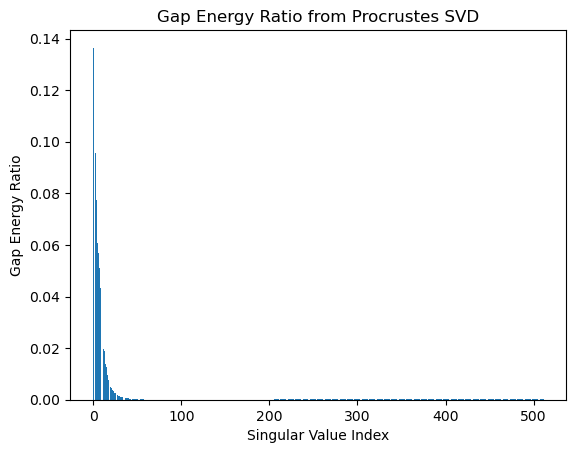

In [75]:
# Let's have fun on the result from procrustes
U, s, Vt = np.linalg.svd(res.t)

gap_energy = (s-1)**2
gap_energy_ratio = gap_energy / np.sum(gap_energy)

# plot on an histogram the gap energy ratio
plt.bar(range(len(gap_energy_ratio)), gap_energy_ratio)
plt.xlabel("Singular Value Index")
plt.ylabel("Gap Energy Ratio")
plt.title("Gap Energy Ratio from Procrustes SVD")
plt.show()

In [74]:
loadings = Vt.T**2  # (d, d), loadings[j,k] = v_{j,k}^2

dim_gap_score = loadings @ gap_energy_ratio  # (d,)

top_dims = np.argsort(-dim_gap_score)[:20]
top_dims, dim_gap_score[top_dims]

(array([361, 347, 210, 363, 339, 429, 105,  43,  44, 145, 199, 194, 422,
        192, 213, 445, 131, 350, 169, 311]),
 array([0.00664708, 0.00525342, 0.00523525, 0.00476214, 0.00453851,
        0.00451194, 0.00450014, 0.00431187, 0.00423514, 0.00420547,
        0.00415297, 0.0040158 , 0.00400734, 0.00390273, 0.00386805,
        0.00377086, 0.00375729, 0.00374559, 0.00352835, 0.00345519],
       dtype=float32))

### Test 2
We run procruster on the first batch and then we see how it behave on the other test batches

In [7]:
# let's get the test dataloader 
_, _, test_loader = get_dataloaders(cf)

batch size: 256
Images (unique) in splits:
  train: 25426 val: 317 test: 6040
Pairs (image,caption) in splits (x5 per image):
  train: 127130 val: 1585 test: 6040


In [ ]:
procrustes_results = []
gaps = ['RMG','L2M','L2I']
gaps_results = {
    'original':{},
    'aligned': {}
}

results = dict()
# 1 Compute Procrustes results for the first batch
# 2 Compute retrieval and gaps for original data in second batch
# 3 Compute the retrieval and the gaps for the second batch but use the t matrix from procrustes to align the embeddings before computing retrieval and gaps (make sure to preprocess the embeddings with the same scaler used in procrustes)
iter_test_loader = iter(test_loader)
first_batch = next(iter_test_loader)
second_batch = next(iter_test_loader)

with torch.no_grad():
    # FIRST BATCH
    images, captions, fns, cap_idxs = first_batch
    images = images.to(device)

    text_emb = text_encoder(captions)
    vision_emb = vision_encoder(images)

    if shared_head is not None:
        text_emb = shared_head(text_emb)
        vision_emb = shared_head(vision_emb)
        
    # normalize the embeddings
    text_emb = F.normalize(text_emb, dim=-1)
    vision_emb = F.normalize(vision_emb, dim=-1)
    
    # Procrustes analysis
    # convert to numpy 
    text_emb = text_emb.cpu().numpy()
    vision_emb = vision_emb.cpu().numpy()
    res = procrustes.generic(text_emb, vision_emb, translate=True, scale=True)
    
    # SECOND BATCH
    text_emb_2 = text_encoder(second_batch[1])
    vision_emb_2 = vision_encoder(second_batch[0].to(device))
    
    if shared_head is not None:
        text_emb_2 = shared_head(text_emb_2)
        vision_emb_2 = shared_head(vision_emb_2)
    
    # normalize the embeddings
    text_emb_2 = F.normalize(text_emb_2, dim=-1)
    vision_emb_2 = F.normalize(vision_emb_2, dim=-1)
    
    # retrieval and gaps for original data in second batch
    text_emb_2_np = text_emb_2.cpu().numpy()
    vision_emb_2_np = vision_emb_2.cpu().numpy()
    retrieval_at_1 = retrieval(text_emb_2_np, vision_emb_2_np)
    for gap in gaps:
        gaps_results['original'][gap] = compute_gap(cf, gap, text_emb_2_np, vision_emb_2_np, None)
        
    print(f"Retrieval@1: {retrieval_at_1:.4f} | Gaps: {gaps_results['original']}")
    # retrieval and gaps for aligned data in second batch
    # compute procrustes alignment for the second batch 
    res2 = procrustes.generic(text_emb_2_np, vision_emb_2_np, translate=True, scale=True)
    new_text_2, new_vision_2 = res2.new_a @ res.t, res2.new_b  # aligned text embeddings
    retrieval_at_1_aligned = retrieval(new_text_2, new_vision_2)
    for gap in gaps:
        gaps_results['aligned'][gap] = compute_gap(cf, gap, new_text_2, new_vision_2, None)
    print(f"Retrieval@1 (aligned): {retrieval_at_1_aligned:.4f} | Gaps (aligned): {gaps_results['aligned']}")
    
    
    

ERROR:tornado.general:SEND Error: Host unreachable


### Test 3
We run procruster on the first N batches, we accumulate the results matrices, then we combine them and we see and then we see how it behave on the others test batches

In [49]:
_, _, test_loader = get_dataloaders(cf)

batch size: 256
Images (unique) in splits:
  train: 25426 val: 317 test: 6040
Pairs (image,caption) in splits (x5 per image):
  train: 127130 val: 1585 test: 6040


In [50]:
def preprocess_translate_scale(A: np.ndarray, eps: float = 1e-12):
    """Center + scale by Frobenius norm (Procrustes-style). A: (N,D)."""
    mu = A.mean(axis=0, keepdims=True)
    A0 = A - mu
    s = np.linalg.norm(A0, ord="fro") + eps
    return A0 / s, mu, s

def orthogonal_procrustes_T(A_pre: np.ndarray, B_pre: np.ndarray):
    """Solve min_T ||A_pre @ T - B_pre||_F s.t. T^T T = I."""
    C = A_pre.T @ B_pre
    U, _, Vt = np.linalg.svd(C, full_matrices=False)
    return U @ Vt

def project_to_orthogonal(M: np.ndarray):
    """Nearest orthogonal matrix via polar projection: M=UΣV^T -> UV^T."""
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    return U @ Vt

def get_batch_embeddings(batch, text_encoder, vision_encoder, shared_head, device):
    images, captions, fns, cap_idxs = batch
    images = images.to(device)

    text_emb = text_encoder(captions)
    vis_emb  = vision_encoder(images)

    if shared_head is not None:
        text_emb = shared_head(text_emb)
        vis_emb  = shared_head(vis_emb)

    text_emb = F.normalize(text_emb, dim=-1)
    vis_emb  = F.normalize(vis_emb, dim=-1)

    return text_emb.detach().cpu().numpy(), vis_emb.detach().cpu().numpy()

def retrieval_at_1(text_np, vis_np):
    # support both retrieval(text, vision) or retrieval(text, vision, top_k=1)
    try:
        return float(retrieval(text_np, vis_np, top_k=1))
    except TypeError:
        return float(retrieval(text_np, vis_np))

def gap_value(cf, gap_name, text_np, vis_np):
    """
    Handles both:
      - compute_gap(...) -> {'text_vision': val, ...}
      - compute_gap(...) -> val
    """
    out = compute_gap(cf, gap_name, text_np, vis_np, None)
    if isinstance(out, dict):
        # prefer 'text_vision' if present
        if "text_vision" in out:
            return float(out["text_vision"])
        # otherwise take the first value
        return float(next(iter(out.values())))
    return float(out)


In [51]:
# --- main routine ---
def mean_rotation_procrustes_20_4_with_gaps(
    cf,
    test_loader,
    text_encoder,
    vision_encoder,
    shared_head,
    device,
    num_fit_batches=20,
    num_test_batches=4,
    eps=1e-12,
    gap_names=("RMG", "L2M", "L2I"),
    renorm_after_align=True,
):
    text_encoder.eval()
    vision_encoder.eval()
    if shared_head is not None:
        shared_head.eval()

    loader_iter = iter(test_loader)

    # 1) FIT: compute per-batch rotations T_b
    Ts = []
    with torch.no_grad():
        for _ in range(num_fit_batches):
            batch = next(loader_iter)
            X, Y = get_batch_embeddings(batch, text_encoder, vision_encoder, shared_head, device)

            Xp, _, _ = preprocess_translate_scale(X, eps=eps)
            Yp, _, _ = preprocess_translate_scale(Y, eps=eps)

            Tb = orthogonal_procrustes_T(Xp, Yp)
            Ts.append(Tb)

    Ts = np.stack(Ts, axis=0)   # (B, D, D)
    T_bar = Ts.mean(axis=0)
    T_star = project_to_orthogonal(T_bar)

    # 2) TEST on next batches
    orig = {
        "retrieval_at_1": [],
        "gaps": {g: [] for g in gap_names}
    }
    aligned = {
        "retrieval_at_1": [],
        "gaps": {g: [] for g in gap_names}
    }

    with torch.no_grad():
        for _ in range(num_test_batches):
            batch = next(loader_iter)
            X, Y = get_batch_embeddings(batch, text_encoder, vision_encoder, shared_head, device)

            # --- original ---
            orig["retrieval_at_1"].append(retrieval_at_1(X, Y))
            for g in gap_names:
                orig["gaps"][g].append(gap_value(cf, g, X, Y))

            # --- aligned (in preprocessed space) ---
            Xp, _, _ = preprocess_translate_scale(X, eps=eps)
            Yp, _, _ = preprocess_translate_scale(Y, eps=eps)

            X_al = Xp @ T_star
            Y_al = Yp

            if renorm_after_align:
                X_al = X_al / (np.linalg.norm(X_al, axis=1, keepdims=True) + eps)
                Y_al = Y_al / (np.linalg.norm(Y_al, axis=1, keepdims=True) + eps)

            aligned["retrieval_at_1"].append(retrieval_at_1(X_al, Y_al))
            for g in gap_names:
                aligned["gaps"][g].append(gap_value(cf, g, X_al, Y_al))

    # 3) report
    def report(tag, d):
        print(f"\n[{tag}]")
        print(f"retrieval@1 mean: {np.mean(d['retrieval_at_1']):.4f} | per-batch: {[round(x,4) for x in d['retrieval_at_1']]}")
        for g in gap_names:
            vals = d["gaps"][g]
            print(f"{g} mean: {np.mean(vals):.4f} | per-batch: {[round(x,4) for x in vals]}")

    print(f"[FIT] batches={num_fit_batches}  [TEST] batches={num_test_batches}")
    report("ORIGINAL", orig)
    report("ALIGNED", aligned)

    return T_star, {
        "T_bar": T_bar,
        "orig": orig,
        "aligned": aligned,
    }

# ---- run it ----
T_star, stats = mean_rotation_procrustes_20_4_with_gaps(
    cf=cf,
    test_loader=test_loader,
    text_encoder=text_encoder,
    vision_encoder=vision_encoder,
    shared_head=shared_head,
    device=device,
    num_fit_batches=20,
    num_test_batches=4,
)

[FIT] batches=20  [TEST] batches=4

[ORIGINAL]
retrieval@1 mean: 0.0830 | per-batch: [0.0664, 0.0742, 0.0859, 0.1053]
RMG mean: 0.6838 | per-batch: [0.6892, 0.6781, 0.6835, 0.6845]
L2M mean: 0.1446 | per-batch: [0.1476, 0.1457, 0.1508, 0.1343]
L2I mean: 0.9836 | per-batch: [0.9885, 0.9746, 0.9844, 0.9868]

[ALIGNED]
retrieval@1 mean: 0.0902 | per-batch: [0.0703, 0.082, 0.0898, 0.1184]
RMG mean: 0.6838 | per-batch: [0.6915, 0.6776, 0.6829, 0.6833]
L2M mean: 0.0133 | per-batch: [0.013, 0.0145, 0.015, 0.0106]
L2I mean: 0.9977 | per-batch: [1.0135, 0.9819, 0.9951, 1.0004]


### Test 4
cluster dependent procruster (semantic modality gap)

In [52]:
train_loader, _, test_loader = get_dataloaders(cf)

batch size: 256
Images (unique) in splits:
  train: 25426 val: 317 test: 6040
Pairs (image,caption) in splits (x5 per image):
  train: 127130 val: 1585 test: 6040


In [53]:
# -----------------------------
# Utilities
# -----------------------------
def l2norm_np(x, eps=1e-12):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def init_centroids_from_batches(
    loader, text_encoder, vision_encoder, shared_head, device,
    K=8, rep="text", num_init_batches=5, seed=0, eps=1e-12
):
    rng = np.random.default_rng(seed)
    Zs = []
    it = iter(loader)

    with torch.no_grad():
        for _ in range(num_init_batches):
            images, captions, *_ = next(it)
            images = images.to(device)

            x = text_encoder(captions)
            y = vision_encoder(images)
            if shared_head is not None:
                x = shared_head(x); y = shared_head(y)

            x = F.normalize(x, dim=-1).cpu().numpy()
            y = F.normalize(y, dim=-1).cpu().numpy()

            if rep == "text":
                z = x
            elif rep == "vision":
                z = y
            elif rep == "joint":
                z = l2norm_np(x + y, eps=eps)
            else:
                raise ValueError("rep must be one of: 'text', 'vision', 'joint'")

            Zs.append(z)

    Z = np.concatenate(Zs, axis=0)
    if Z.shape[0] < K:
        raise ValueError(f"Not enough samples to init {K} centroids. Got {Z.shape[0]} samples.")

    idx = rng.choice(Z.shape[0], size=K, replace=False)
    C = Z[idx].copy()
    C = l2norm_np(C, eps=eps)  # normalize centroids for cosine assignment
    return C

def assign_to_centroids(Z, C):
    # cosine similarity assignment (both are normalized)
    sims = Z @ C.T  # (N, K)
    return np.argmax(sims, axis=1)

def update_centroids_minibatch(C, counts, Z, assign, eps=1e-12):
    # streaming k-means centroid update using batch means
    K = C.shape[0]
    for k in range(K):
        mask = (assign == k)
        if not np.any(mask):
            continue
        Zk = Z[mask]
        nk_old = counts[k]
        nk_new = nk_old + Zk.shape[0]
        mean_Zk = Zk.mean(axis=0)

        if nk_old == 0:
            C[k] = mean_Zk
        else:
            C[k] = (nk_old * C[k] + Zk.shape[0] * mean_Zk) / nk_new

        # normalize centroid
        C[k] = C[k] / (np.linalg.norm(C[k]) + eps)
        counts[k] = nk_new

def reservoir_update(reservoir, reservoir_seen, k, Xk, Yk, cap=512, seed=0):
    """
    Per-cluster reservoir sampling to keep up to 'cap' pairs for later diagnostics.
    reservoir[k] holds dict with keys 'X' and 'Y' as lists of np arrays (rows).
    reservoir_seen[k] counts how many points have been observed for that cluster.
    """
    rng = np.random.default_rng(seed + k)

    for i in range(Xk.shape[0]):
        reservoir_seen[k] += 1
        t = reservoir_seen[k]

        if len(reservoir[k]["X"]) < cap:
            reservoir[k]["X"].append(Xk[i])
            reservoir[k]["Y"].append(Yk[i])
        else:
            # replace with prob cap/t
            j = rng.integers(0, t)
            if j < cap:
                reservoir[k]["X"][j] = Xk[i]
                reservoir[k]["Y"][j] = Yk[i]

def frob_dist(A, B):
    return float(np.linalg.norm(A - B, ord="fro"))

# -----------------------------
# Main: partial streaming clustering + cluster Procrustes diagnostics
# -----------------------------
def streaming_clusters_with_procrustes_diagnostics(
    train_loader,
    text_encoder,
    vision_encoder,
    shared_head,
    device,
    K=8,
    rep="text",                 # "text" | "vision" | "joint"
    max_batches=200,            # partial observation: stop after this many batches
    num_init_batches=5,
    reservoir_cap=512,          # how many pairs per cluster kept for Procrustes
    procrustes_translate=True,
    procrustes_scale=True,
    seed=0,
    eps=1e-12
):
    text_encoder.eval()
    vision_encoder.eval()
    if shared_head is not None:
        shared_head.eval()

    # 1) init global centroids from first few batches
    C = init_centroids_from_batches(
        train_loader, text_encoder, vision_encoder, shared_head, device,
        K=K, rep=rep, num_init_batches=num_init_batches, seed=seed, eps=eps
    )
    counts = np.zeros(K, dtype=np.int64)

    # reservoirs for later per-cluster Procrustes
    reservoir = {k: {"X": [], "Y": []} for k in range(K)}
    reservoir_seen = np.zeros(K, dtype=np.int64)

    # 2) stream batches
    it = iter(train_loader)
    with torch.no_grad():
        for b in tqdm(range(max_batches), desc=f"Streaming {max_batches} batches (rep={rep}, K={K})"):
            try:
                images, captions, *_ = next(it)
            except StopIteration:
                break

            images = images.to(device)
            x = text_encoder(captions)
            y = vision_encoder(images)
            if shared_head is not None:
                x = shared_head(x); y = shared_head(y)

            x = F.normalize(x, dim=-1).cpu().numpy()
            y = F.normalize(y, dim=-1).cpu().numpy()

            if rep == "text":
                Z = x
            elif rep == "vision":
                Z = y
            elif rep == "joint":
                Z = l2norm_np(x + y, eps=eps)
            else:
                raise ValueError("rep must be one of: 'text', 'vision', 'joint'")

            # assign and update centroids
            assign = assign_to_centroids(Z, C)
            update_centroids_minibatch(C, counts, Z, assign, eps=eps)

            # update reservoirs per cluster (store paired (text, vision) points)
            for k in range(K):
                mask = (assign == k)
                if not np.any(mask):
                    continue
                reservoir_update(
                    reservoir, reservoir_seen,
                    k, Xk=x[mask], Yk=y[mask],
                    cap=reservoir_cap, seed=seed
                )

    # 3) diagnostics: cluster sizes
    print("\nCluster counts (assigned points seen):")
    for k in range(K):
        print(f"  cluster {k}: {counts[k]}")

    # centroid cosine similarity matrix (are clusters distinct?)
    centroid_sim = C @ C.T
    print("\nCentroid cosine similarity matrix (higher off-diagonal => less distinct):")
    np.set_printoptions(precision=3, suppress=True)
    print(centroid_sim)

    # 4) per-cluster Procrustes using procrustes.generic on reservoir samples
    Ts = []
    errs = []
    valid = []

    for k in range(K):
        X_list = reservoir[k]["X"]
        Y_list = reservoir[k]["Y"]
        if len(X_list) < 10:
            Ts.append(None); errs.append(None); valid.append(False)
            continue

        Xk = np.stack(X_list, axis=0)  # (n, d)
        Yk = np.stack(Y_list, axis=0)  # (n, d)

        res = procrustes.generic(
            Xk, Yk,
            translate=procrustes_translate,
            scale=procrustes_scale
        )
        Ts.append(res.t)
        # many versions store error as float, sometimes as np scalar
        err_val = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())
        errs.append(err_val)
        valid.append(True)

    print("\nPer-cluster Procrustes fit error (lower => easier to align within cluster):")
    for k in range(K):
        if valid[k]:
            print(f"  cluster {k}: error={errs[k]:.6f} | reservoir_n={len(reservoir[k]['X'])}")
        else:
            print(f"  cluster {k}: not enough samples")

    # 5) compare T_k matrices (do they differ meaningfully?)
    # Build pairwise Frobenius distances between rotations
    print("\nPairwise Frobenius distances between cluster rotations T_k:")
    Tdist = np.full((K, K), np.nan, dtype=np.float64)
    for i in range(K):
        for j in range(K):
            if valid[i] and valid[j]:
                Tdist[i, j] = frob_dist(Ts[i], Ts[j])
    print(Tdist)

    return {
        "centroids": C,
        "counts": counts,
        "reservoir": reservoir,
        "Tk": Ts,
        "procrustes_error": errs,
        "Tdist": Tdist,
        "centroid_sim": centroid_sim,
        "valid_clusters": valid,
    }


In [54]:
stats = streaming_clusters_with_procrustes_diagnostics(
    train_loader=train_loader,           # your Flickr30k train loader
    text_encoder=text_encoder,
    vision_encoder=vision_encoder,
    shared_head=shared_head,
    device=device,
    K=8,
    rep="text",                          # try "text" first (semantic)
    max_batches=200,                     # partial observation (increase gradually)
    reservoir_cap=512,
    procrustes_translate=True,
    procrustes_scale=True,
    seed=0
)


Streaming 200 batches (rep=text, K=8): 100%|██████████| 200/200 [01:01<00:00,  3.25it/s]



Cluster counts (assigned points seen):
  cluster 0: 6908
  cluster 1: 7475
  cluster 2: 5733
  cluster 3: 7054
  cluster 4: 7018
  cluster 5: 3279
  cluster 6: 5328
  cluster 7: 8405

Centroid cosine similarity matrix (higher off-diagonal => less distinct):
[[ 1.     0.032 -0.336  0.252 -0.422 -0.099  0.311  0.031]
 [ 0.032  1.    -0.509  0.085 -0.402 -0.427 -0.154  0.425]
 [-0.336 -0.509  1.    -0.415  0.028  0.321  0.071 -0.401]
 [ 0.252  0.085 -0.415  1.    -0.207 -0.245 -0.176  0.031]
 [-0.422 -0.402  0.028 -0.207  1.    -0.038 -0.102 -0.152]
 [-0.099 -0.427  0.321 -0.245 -0.038  1.     0.145 -0.378]
 [ 0.311 -0.154  0.071 -0.176 -0.102  0.145  1.    -0.38 ]
 [ 0.031  0.425 -0.401  0.031 -0.152 -0.378 -0.38   1.   ]]

Per-cluster Procrustes fit error (lower => easier to align within cluster):
  cluster 0: error=0.339550 | reservoir_n=512
  cluster 1: error=0.307936 | reservoir_n=512
  cluster 2: error=0.321144 | reservoir_n=512
  cluster 3: error=0.292595 | reservoir_n=512
  clust

## PCA

In [ ]:
# PCA visualization for the original and aligned embeddings
def plot_embeddings(text_emb, vision_emb, title):
    
    all_emb = np.vstack((text_emb, vision_emb))
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=3, random_state=getattr(cf, "seed", None))
    )
    pca_result = pipe.fit_transform(all_emb)
    text_pca = pca_result[:len(text_emb)]
    vision_pca = pca_result[len(text_emb):]
    

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(text_pca[:, 0], text_pca[:, 1], text_pca[:, 2],
               marker="*", s=60, label="Text")
    ax.scatter(vision_pca[:, 0], vision_pca[:, 1], vision_pca[:, 2],
               marker="s", s=60, label="Vision")

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.set_title(f"PCA 3D (shared space)")
    ax.legend()



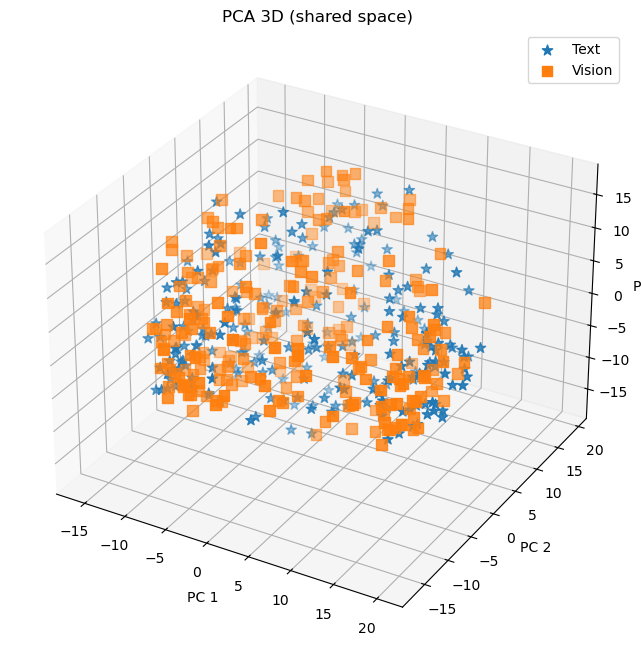

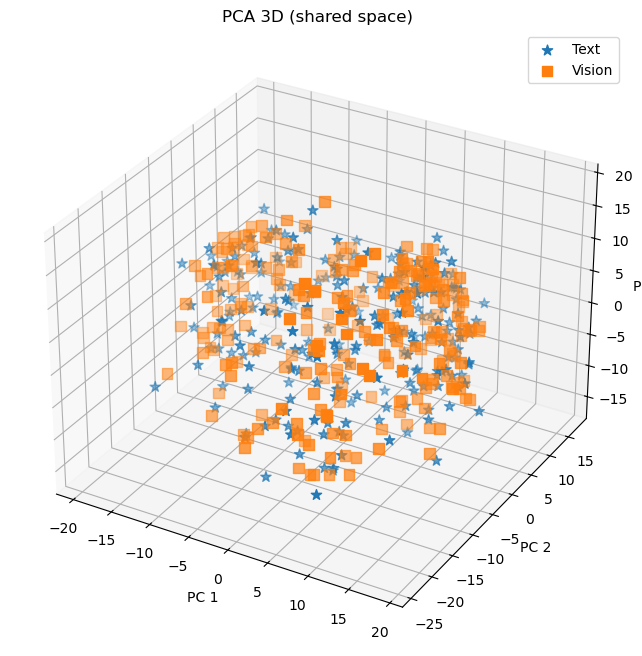

In [58]:
plot_embeddings(text_emb, vision_emb, "Original Embeddings")
plot_embeddings(new_text, new_vision, "Procrustes-Aligned Embeddings")